Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import pickle

In [ ]:
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
df.shape

(7043, 21)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info() #to check any missing values and data type are present

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


From this all are non null values

Data Loading

In [ ]:
#dropping customer id (not useful for prediction)
df=df.drop(columns=['customerID'])

In [ ]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
print(df["gender"].unique())

['Female' 'Male']


In [ ]:
#print unique values for each column

for col in df.columns:
  print(col, df[col].unique())
  print('\n')

gender ['Female' 'Male']


SeniorCitizen [0 1]


Partner ['Yes' 'No']


Dependents ['No' 'Yes']


tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]


PhoneService ['No' 'Yes']


MultipleLines ['No phone service' 'No' 'Yes']


InternetService ['DSL' 'Fiber optic' 'No']


OnlineSecurity ['No' 'Yes' 'No internet service']


OnlineBackup ['Yes' 'No' 'No internet service']


DeviceProtection ['No' 'Yes' 'No internet service']


TechSupport ['No' 'Yes' 'No internet service']


StreamingTV ['No' 'Yes' 'No internet service']


StreamingMovies ['No' 'Yes' 'No internet service']


Contract ['Month-to-month' 'One year' 'Two year']


PaperlessBilling ['Yes' 'No']


PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


MonthlyCharges [29.85 56.95 53.85 ... 63.1  44.2  

In [ ]:
#print unique values in categorical feature

numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in df.columns:
  if col not in numerical_features:
    print(col, df[col].unique())
    print('\n')

gender ['Female' 'Male']


SeniorCitizen [0 1]


Partner ['Yes' 'No']


Dependents ['No' 'Yes']


PhoneService ['No' 'Yes']


MultipleLines ['No phone service' 'No' 'Yes']


InternetService ['DSL' 'Fiber optic' 'No']


OnlineSecurity ['No' 'Yes' 'No internet service']


OnlineBackup ['Yes' 'No' 'No internet service']


DeviceProtection ['No' 'Yes' 'No internet service']


TechSupport ['No' 'Yes' 'No internet service']


StreamingTV ['No' 'Yes' 'No internet service']


StreamingMovies ['No' 'Yes' 'No internet service']


Contract ['Month-to-month' 'One year' 'Two year']


PaperlessBilling ['Yes' 'No']


PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


Churn ['No' 'Yes']




In [ ]:
#count no.of missing values
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
# converting the data type of total charges (object to float)
df['TotalCharges']= df['TotalCharges'].astype(float)

ValueError: could not convert string to float: ' '

In [ ]:
df[df['TotalCharges']==" "]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [ ]:
len(df[df["TotalCharges"]==" "])

In [ ]:
df['TotalCharges'] = df['TotalCharges'].replace(" ","0.0")

In [ ]:
# converting the data type of total charges (object to float)
df['TotalCharges']= df['TotalCharges'].astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


In [ ]:
# to checck class imbalance in tarhet column(churn)

df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


From this we can understand that there is an imbalance in the target column which gives a prediction as "No" to obtain higher accuracy

EDA

In [ ]:
df.shape

(7043, 20)

In [ ]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [ ]:
df.describe() #works only on numerical data not categorical

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Numerical Data Analysis

In [ ]:
def plot_graph(df, col_name):
  plt.figure(figsize=(5,3))
  sns.histplot(df[col_name],kde=True)
  plt.title(f"Distribution of {col_name}")

  # Calculate mean and median
  col_mean = df[col_name].mean()
  col_median = df[col_name].median()

  plt.axvline(col_mean, color='red', linestyle='-',label='Mean')
  plt.axvline(col_median, color='green', linestyle='--',label='Median')

  plt.legend()
  plt.show()

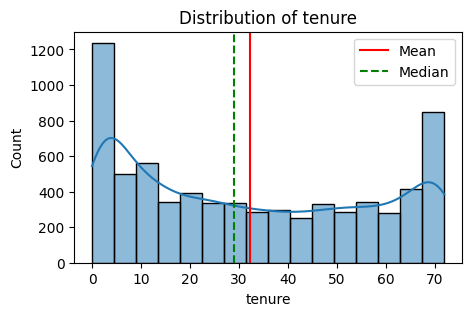

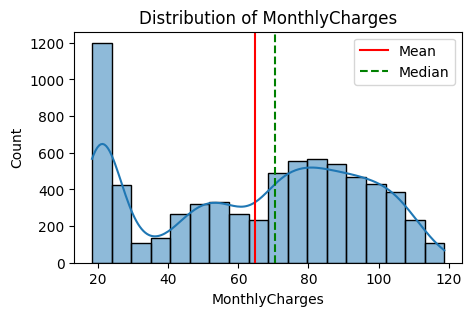

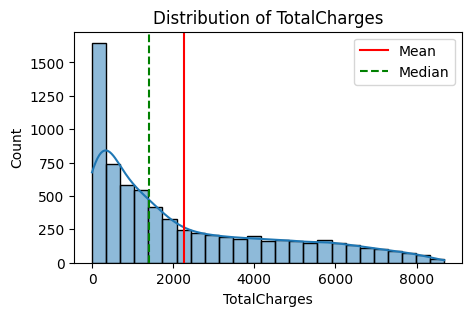

In [ ]:
plot_graph(df,'tenure')
plot_graph(df,'MonthlyCharges')
plot_graph(df,'TotalCharges')

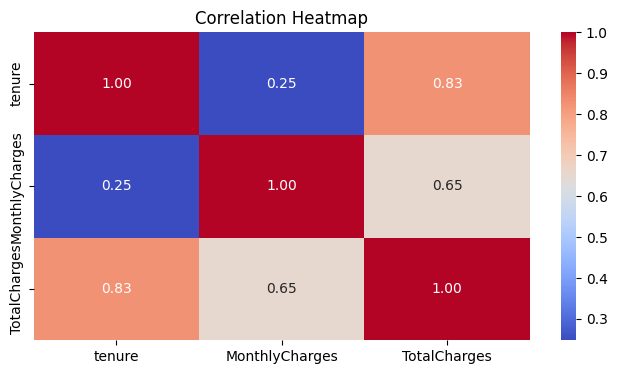

In [ ]:
# correlation matrix - heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Categorical Columns analysis

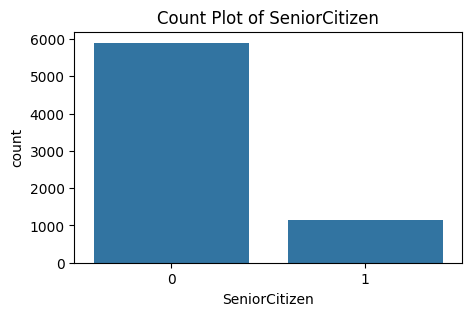

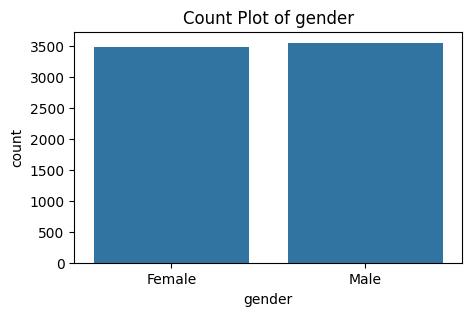

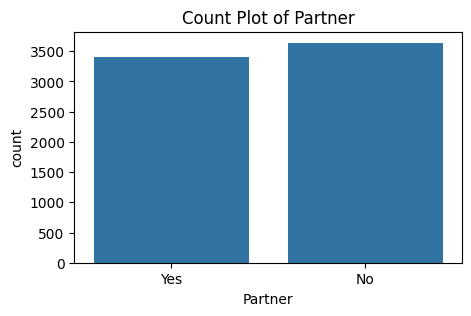

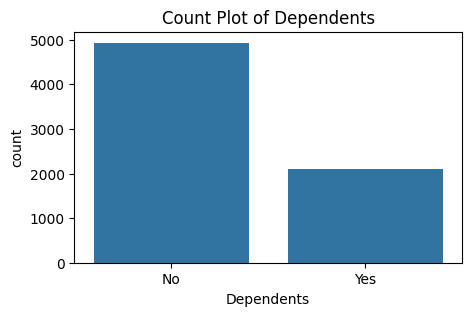

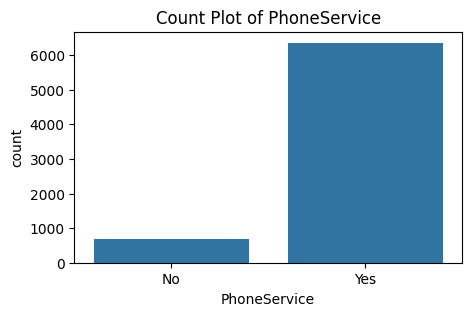

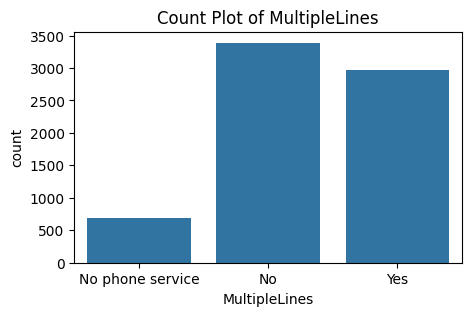

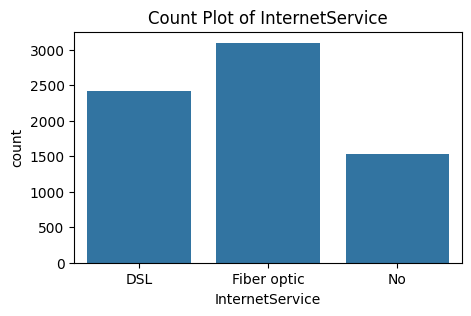

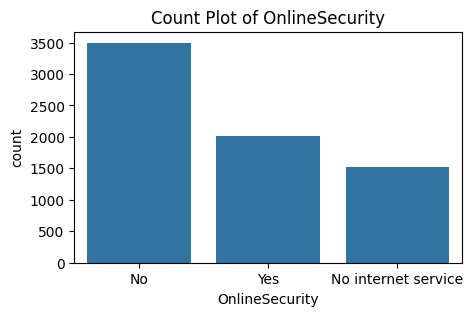

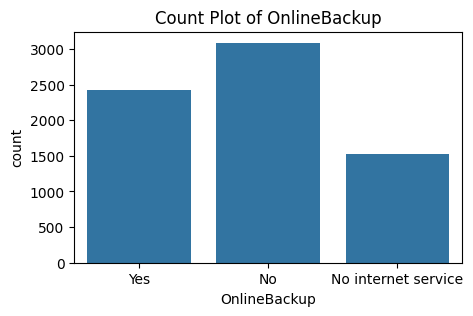

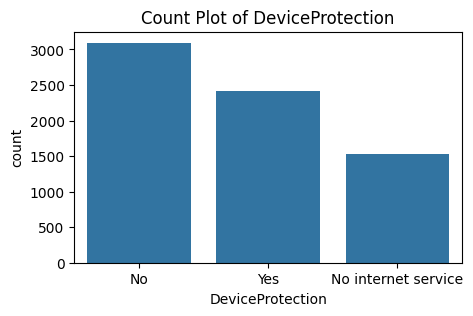

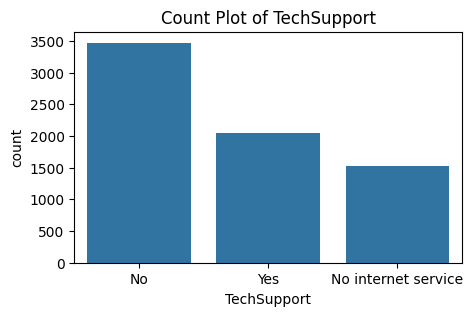

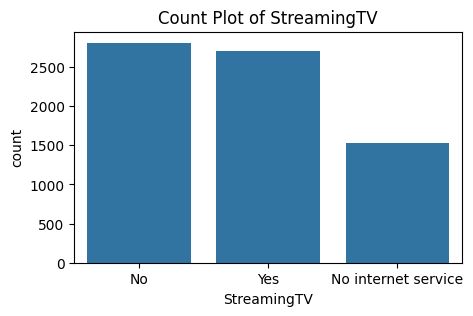

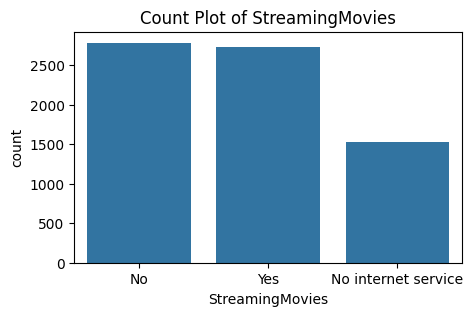

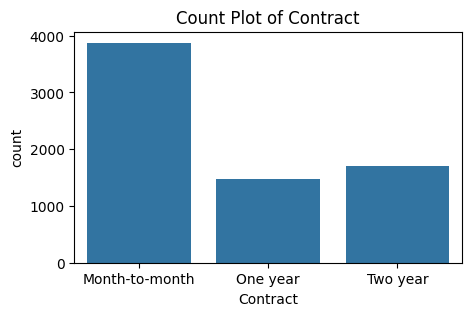

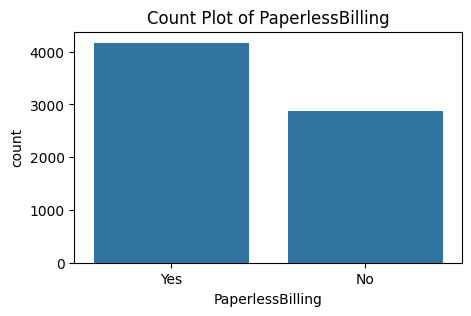

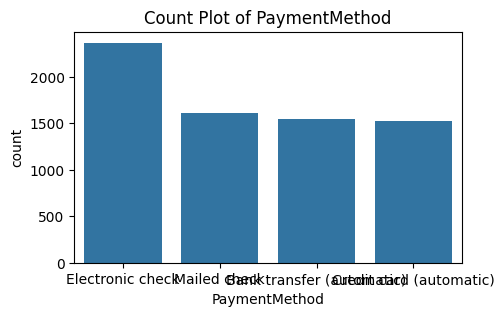

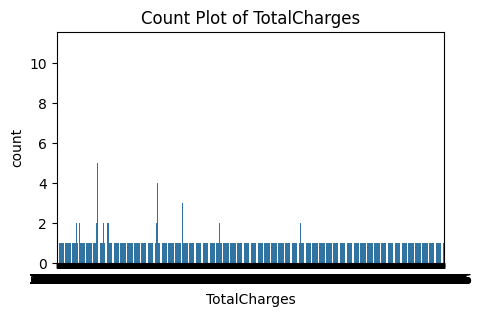

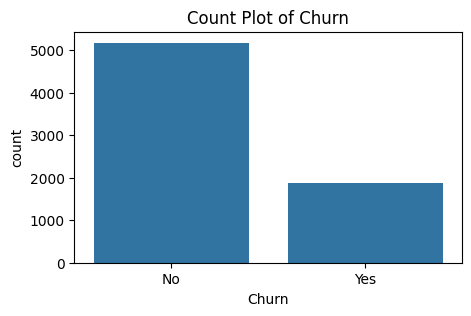

In [ ]:
object_cols = df.select_dtypes(include="object").columns.to_list()

object_cols = ["SeniorCitizen"] + object_cols

for col in object_cols:
  plt.figure(figsize=(5, 3))
  sns.countplot(x=df[col])
  plt.title(f"Count Plot of {col}")
  plt.show()

Data Preprocessing

In [ ]:
df.head(3)

In [ ]:
# label encoding target column (churn)
df['Churn'] = df['Churn'].replace({"Yes": 1, "No": 0})

In [ ]:
df['Churn']

In [ ]:
# label encoding for all other categorical datatype
# columns with object datatype

object_col=df.select_dtypes(include="object").columns
print(object_col)

In [ ]:
encoders={}

for col in object_col:
  label_encoder=LabelEncoder()
  df[col] = label_encoder.fit_transform(df[col])
  encoders[col]=  label_encoder

with open("encoders.pkl","wb") as f:
  pickle.dump(encoders,f)

In [76]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [ ]:
df.head(2)

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
X=df.drop(columns=['Churn'])
Y=df['Churn']

In [ ]:
X_Train,X_Test,Y_Train,Y_Test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [77]:
print(Y_Train.value_counts())


Churn
0    4138
1    1496
Name: count, dtype: int64


SMOTE - Synthetic Minority Oversampling Technique:This is to because the dataset is imbalanced which is shown above. There is a lot more Nos than Yes Churns. SMOTE creates more synthetic examples of the minority classes. This makes the minority class more diverse and improves the model accuracy

In [ ]:
smote=SMOTE(random_state=42)
X_Train_smote,Y_Train_smote=smote.fit_resample(X_Train,Y_Train)
print(Y_Train_smote.value_counts())

In [ ]:
models= {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=500, random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}

NameError: name 'DecisionTreeClassifier' is not defined

In [ ]:
cv_scores = {}

for model_name, model in models.items():
    print(f"Training {model_name} with default parameters")

    # Perform 5-fold cross-validation
    scores = cross_val_score(model, X_Train_smote, Y_Train_smote, cv=5, scoring="accuracy")

    # Convert to percentage
    scores_percent = scores * 100
    mean_percent = np.mean(scores_percent)

    # Store the original scores if needed
    cv_scores[model_name] = scores_percent

    # Print fold-wise and mean accuracy in percent
    print(f"{model_name} fold-wise accuracy (%): {scores_percent}")
    print(f"{model_name} cross-validation mean accuracy (%): {mean_percent:.2f}%")
    print("-"*70)


NameError: name 'models' is not defined

In [78]:
cv_scores = {}

for model_name, model in models.items():
  print(f"Training {model_name} with default parameters")
  scores = cross_val_score(model, X_Train_smote, Y_Train_smote, cv=5, scoring="accuracy")
  cv_scores[model_name] = scores
  print(f"{model_name} cross-validation accuracy: {np.mean(scores):.2f}")
  print("-"*70)

Training Decision Tree with default parameters
Decision Tree cross-validation accuracy: 0.78
----------------------------------------------------------------------
Training Random Forest with default parameters
Random Forest cross-validation accuracy: 0.84
----------------------------------------------------------------------
Training XGBoost with default parameters
XGBoost cross-validation accuracy: 0.83
----------------------------------------------------------------------
Training Logistic Regression with default parameters


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression cross-validation accuracy: 0.79
----------------------------------------------------------------------
Training LightGBM with default parameters
[LightGBM] [Info] Number of positive: 3310, number of negative: 3310
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001452 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 626
[LightGBM] [Info] Number of data points in the train set: 6620, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 3311, number of negative: 3310
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001002 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 626
[LightGB

In [ ]:
cv_scores

The highest accuracy is RandomForest with 0.84

In [ ]:
RFC=RandomForestClassifier(random_state=42)
RFC.fit(X_Train_smote, Y_Train_smote)

In [79]:
print(Y_Test.value_counts())

Churn
0    1036
1     373
Name: count, dtype: int64


In [ ]:
Y_Test_pred = RFC.predict(X_Test)

print("Accuracy Score:\n", accuracy_score(Y_Test, Y_Test_pred))
print("Confsuion Matrix:\n", confusion_matrix(Y_Test, Y_Test_pred))
print("Classification Report:\n", classification_report(Y_Test, Y_Test_pred))

Accuracy Score:
 0.7785663591199432
Confsuion Matrix:
 [[878 158]
 [154 219]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.58      0.59      0.58       373

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

# Define parameter distributions for random search
param_dist = {
    'n_estimators': randint(100, 500),        # Random values between 100 and 500
    'max_depth': [5, 10, 20, None],
    'min_samples_split': randint(2, 11),      # Random values between 2 and 10
    'min_samples_leaf': randint(1, 5),        # Random values between 1 and 4
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', None]
}

rf = RandomForestClassifier(random_state=42)

# Setup RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,            # Number of random parameter combinations to try
    cv=3,
    scoring='f1',         # Focus on churn class
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# Fit on SMOTE-resampled training data
random_search.fit(X_Train_smote, Y_Train_smote)

# Get the best model
best_rf = random_search.best_estimator_
print("Best parameters found:", random_search.best_params_)
print("Best F1 score:", random_search.best_score_)


In [ ]:
# Use the tuned best model
best_model = random_search.best_estimator_

Y_Test_pred = best_model.predict(X_Test)

print("Accuracy Score:\n", accuracy_score(Y_Test, Y_Test_pred))
print("Confusion Matrix:\n", confusion_matrix(Y_Test, Y_Test_pred))
print("Classification Report:\n", classification_report(Y_Test, Y_Test_pred))


Accuracy Score:
 0.7721788502484032
Confusion Matrix:
 [[839 197]
 [124 249]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.81      0.84      1036
           1       0.56      0.67      0.61       373

    accuracy                           0.77      1409
   macro avg       0.71      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409



In [ ]:
import pickle

model_data = {
    "model": best_rf,  # or best_xgb
    "features_names": X.columns.tolist()
}

with open("customer_churn_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

print("Tuned model saved successfully!")


Prediction with the Model that yielded the best accuracy

In [ ]:
with open("customer_churn_model.pkl", "rb") as f:
  model_data = pickle.load(f)

loaded_model = model_data["model"]
feature_names = model_data["features_names"]

In [ ]:
print(loaded_model)
print(feature_names)

In [ ]:
input_data = {
    'gender': 'Male',
    'SeniorCitizen': 0,
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'Yes',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'Yes',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'No',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85
}


input_data_df = pd.DataFrame([input_data])

with open("encoders.pkl", "rb") as f:
  encoders = pickle.load(f)


for column, encoder in encoders.items():
  input_data_df[column] = encoder.transform(input_data_df[column])

prediction = loaded_model.predict(input_data_df)
pred_prob = loaded_model.predict_proba(input_data_df)

print(prediction)

# results
print(f"Prediction: {'Churn' if prediction[0] == 1 else 'No Churn'}")
print(f"Prediciton Probability: {pred_prob}")

threshold = 0.4  # predict Churn if probability >= 0.4
prediction_custom = (pred_prob[:, 1] >= threshold).astype(int)
print(f"Prediction with custom threshold: {'Churn' if prediction_custom[0] == 1 else 'No Churn'}")


[1]
Prediction: Churn
Prediciton Probability: [[0.38358564 0.61641436]]
Prediction with custom threshold: Churn
